In [1]:
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv(override=True) 

from lxml import etree # for importing other dataset that has 'alim_nom_fr' + 'ALIM_INDEX_FR' columns


### ciqual data english

In [2]:
CIQUAL_DATA = os.getenv("CIQUAL_DATA")


df_ciqual = pd.read_excel(CIQUAL_DATA)



/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [3]:
df_ciqual.head()

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, Regulation EU No 1169/2011 (kJ/100g)",...,Vitamin K1 (µg/100g),Vitamin K2 (µg/100g),Vitamin C (mg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g)
0,0,0,0,NaN,NaN,NaN,24999,Desert (average),NaN,NaN,...,NaN,NaN,"1,37","0,084","0,15","0,61","0,4","0,056","30,8","0,21"
1,1,101,0,starters and dishes,mixed salads,-,25601,"Prepared mixed tuna and vegetable salad, canned",NaN,-,...,-,-,"2,75","< 0,04","0,053","4,45","< 0,16","0,29",31,"1,45"
2,1,101,0,starters and dishes,mixed salads,-,25602,"Prepared mixed meat/fish canned, salad",NaN,-,...,"9,75",-,-,"0,032","0,022","4,13","0,2","0,12","11,1","1,23"
3,1,101,0,starters and dishes,mixed salads,-,25605,"Greek-style marinated mushrooms, prepacked",NaN,-,...,-,-,"6,67","0,056","0,21","1,84","0,88","0,088","19,6","0,018"
4,1,101,0,starters and dishes,mixed salads,-,25606,"Prepared potatoes salad, home-made",NaN,-,...,-,-,10,"0,077","0,06","0,89","0,53","0,14",7,0


In [4]:
df_ciqual.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3186 entries, 0 to 3185
Data columns (total 76 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   alim_grp_code                                       3186 non-null   int64 
 1   alim_ssgrp_code                                     3186 non-null   int64 
 2   alim_ssssgrp_code                                   3186 non-null   int64 
 3   alim_grp_nom_eng                                    3141 non-null   object
 4   alim_ssgrp_nom_eng                                  3141 non-null   object
 5   alim_ssssgrp_nom_eng                                3141 non-null   object
 6   alim_code                                           3186 non-null   int64 
 7   alim_nom_eng                                        3186 non-null   object
 8   alim_nom_sci                                        270 non-null    object
 9   Energy, 

In [5]:
df_ciqual.columns

Index(['alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
       'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
       'alim_code', 'alim_nom_eng', 'alim_nom_sci',
       'Energy, Regulation EU No 1169/2011 (kJ/100g)',
       'Energy, Regulation EU No 1169/2011 (kcal/100g)',
       'Energy, N x Jones' factor, with fibres (kJ/100g)',
       'Energy, N x Jones' factor, with fibres (kcal/100g)', 'Water (g/100g)',
       'Protein (g/100g)', 'Protein, crude, N x 6.25 (g/100g)',
       'Carbohydrate (g/100g)', 'Fat (g/100g)', 'Sugars (g/100g)',
       'fructose (g/100g)', 'galactose (g/100g)', 'glucose (g/100g)',
       'lactose (g/100g)', 'maltose (g/100g)', 'sucrose (g/100g)',
       'Starch (g/100g)', 'Fibres (g/100g)', 'Polyols (g/100g)',
       'Ash (g/100g)', 'Alcohol (g/100g)', 'Organic acids (g/100g)',
       'FA saturated (g/100g)', 'FA mono (g/100g)', 'FA poly (g/100g)',
       'FA 4:0 (g/100g)', 'FA 6:0 (g/100g)', 'FA 8:0 (g/100g)',
       'FA 10:0 (g/100g

In [6]:
df_compare = df_ciqual[['alim_code', 'alim_nom_eng', 
                        'alim_grp_nom_eng', 
                        'alim_ssgrp_nom_eng', 
                        "Protein (g/100g)",
                        "Fat (g/100g)",
                        "Carbohydrate (g/100g)",
                        "Energy, Regulation EU No 1169/2011 (kcal/100g)",
                        "Fibres (g/100g)",
                        "Iron (mg/100g)",
                        "Iodine (µg/100g)",
                        "Calcium (mg/100g)",
                        "Magnesium (mg/100g)",
                        "Vitamin B12 (µg/100g)",
                        "Vitamin C (mg/100g)",
                        "FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)",
                        "FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"]]

In [7]:
df_compare.head()

,alim_code,alim_nom_eng,alim_grp_nom_eng,alim_ssgrp_nom_eng,Protein (g/100g),Fat (g/100g),Carbohydrate (g/100g),"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fibres (g/100g),Iron (mg/100g),Iodine (µg/100g),Calcium (mg/100g),Magnesium (mg/100g),Vitamin B12 (µg/100g),Vitamin C (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
0,24999,Desert (average),NaN,NaN,"4,63","12,9","36,6",NaN,"1,54","1,45",11,75,"23,8","0,21","1,37","0,0041","0,0051"
1,25601,"Prepared mixed tuna and vegetable salad, canned",starters and dishes,mixed salads,"9,15","4,7","7,74",-,"2,7","1,1",2,"20,7","25,1","1,45","2,75","0,008","0,039"
2,25602,"Prepared mixed meat/fish canned, salad",starters and dishes,mixed salads,"8,06","5,3","6,4",-,2,"0,7",< 20,22,20,"1,23",-,"0,016","0,15"
3,25605,"Greek-style marinated mushrooms, prepacked",starters and dishes,mixed salads,"2,08","3,55","3,95",-,"2,35","1,06","2,46",27,"13,5","0,018","6,67",-,-
4,25606,"Prepared potatoes salad, home-made",starters and dishes,mixed salads,"2,68","8,2","9,9",-,"1,3","0,65",-,19,15,0,10,-,-


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df_compare = df_compare.copy().fillna(value=0)



In [10]:
nutrient_cols = ["alim_code", 
                  "Protein (g/100g)",
                    "Fat (g/100g)",
                    "Carbohydrate (g/100g)",
                    "Energy, Regulation EU No 1169/2011 (kcal/100g)",
                    "Fibres (g/100g)",
                    "Iron (mg/100g)",
                    "Iodine (µg/100g)",
                    "Calcium (mg/100g)",
                    "Magnesium (mg/100g)",
                    "Vitamin B12 (µg/100g)",
                    "Vitamin C (mg/100g)",
                    "FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)",
                    "FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"]

In [11]:
for col in nutrient_cols:
    print(f"\nColumn: {col}")
    print(df_compare[col].value_counts(dropna=False).head(10))  # check top 10 most common values



Column: alim_code
alim_code
9621     2
24999    1
12814    1
12052    1
12064    1
12801    1
12802    1
12803    1
12807    1
12810    1
Name: count, dtype: int64

Column: Protein (g/100g)
Protein (g/100g)
0        178
< 0,5     70
0,63      20
-         18
1,13      15
0,69      15
10,3      15
19        15
18,8      15
18        14
Name: count, dtype: int64

Column: Fat (g/100g)
Fat (g/100g)
0        179
< 0,5     93
< 0,3     44
0,1       39
0,3       34
100       30
0,2       26
0,4       24
0,5       24
0,7       21
Name: count, dtype: int64

Column: Carbohydrate (g/100g)
Carbohydrate (g/100g)
traces    328
0         300
-          81
0,4        17
0,5        17
1          17
0,6        13
0,3        13
13         13
11,9       11
Name: count, dtype: int64

Column: Energy, Regulation EU No 1169/2011 (kcal/100g)
Energy, Regulation EU No 1169/2011 (kcal/100g)
-      871
0       97
900     32
0       17
133     16
147     13
168     12
121     12
246     12
132     12
Name: count, 

In [12]:
def clean_nutrient_dataframe(df, nutrient_columns, replacement_map=None, approx_multiplier=0.75, verbose=True):
    """
    Cleans and normalizes nutrient data from a DataFrame.

    Parameters:
    - df (pd.DataFrame): The input DataFrame to clean.
    - nutrient_columns (list): List of column names to clean.
    - replacement_map (dict, optional): Custom replacements for values like 'traces', '-', etc.
    - approx_multiplier (float, optional): Multiplier to apply to values marked as approximations (e.g., "< 0.1").
    - verbose (bool): If True, prints non-numeric warnings and NaN summary.

    Returns:
    - df_cleaned (pd.DataFrame): Cleaned DataFrame with float values and approximation tracking.
    """
    # Default replacements if none provided
    if replacement_map is None:
        replacement_map = {
            "traces": "0.000001",
            "-": np.nan,
            "nan": np.nan,
            "NaN": np.nan,
            "NAN": np.nan,
            "None": np.nan,
            "": np.nan,
            "[nan]": np.nan,
            "n/a": np.nan,
            "nd": np.nan
        }

    # Deep copy to avoid modifying original
    df_cleaned = df.copy()

    # Initialize approximation mask
    approx_mask = pd.DataFrame(False, index=df_cleaned.index, columns=nutrient_columns)

    for col in nutrient_columns:
        # Convert to string and strip whitespace
        col_str = df_cleaned[col].astype(str).str.strip()

        # Detect and mark approximations
        is_approx = col_str.str.startswith("< ")
        approx_mask[col] = is_approx

        # Clean approximation values
        col_str.loc[is_approx] = (
            col_str.loc[is_approx]
            .str.replace("< ", "", regex=False)
            .str.replace(",", ".", regex=False)
        )

        # Apply replacements
        col_str = col_str.replace(replacement_map, regex=False).astype(str)

        # Normalize decimal commas
        col_str = col_str.str.replace(",", ".", regex=False)


        # Coerce to numeric and log problematic values
        coerced = col_str[~col_str.isna() & pd.to_numeric(col_str, errors='coerce').isna()]
        if verbose and not coerced.empty:
            print(f" Coerced to NaN in '{col}': {coerced.unique()}")

        # Convert to float
        df_cleaned[col] = pd.to_numeric(col_str, errors='coerce')

        # Step 7: Apply approximation multiplier
        df_cleaned.loc[is_approx, col] *= approx_multiplier

    # Step 8: Ensure float type
    df_cleaned[nutrient_columns] = df_cleaned[nutrient_columns].astype(float)

    # Step 9: Add count of approximated values per row
    df_cleaned["approx_count"] = approx_mask.sum(axis=1)

    # Step 10: Final NaN check
    if verbose:
        print("\nNaN count after cleaning:")
        print(df_cleaned[nutrient_columns].isna().sum())

        print("\nApproximation counts per column:")
        print(approx_mask.sum())

    return df_cleaned


In [13]:
df_compare

,alim_code,alim_nom_eng,alim_grp_nom_eng,alim_ssgrp_nom_eng,Protein (g/100g),Fat (g/100g),Carbohydrate (g/100g),"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fibres (g/100g),Iron (mg/100g),Iodine (µg/100g),Calcium (mg/100g),Magnesium (mg/100g),Vitamin B12 (µg/100g),Vitamin C (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
0,24999,Desert (average),0,0,"4,63","12,9","36,6",0,"1,54","1,45",11,75,"23,8","0,21","1,37","0,0041","0,0051"
1,25601,"Prepared mixed tuna and vegetable salad, canned",starters and dishes,mixed salads,"9,15","4,7","7,74",-,"2,7","1,1",2,"20,7","25,1","1,45","2,75","0,008","0,039"
2,25602,"Prepared mixed meat/fish canned, salad",starters and dishes,mixed salads,"8,06","5,3","6,4",-,2,"0,7",< 20,22,20,"1,23",-,"0,016","0,15"
3,25605,"Greek-style marinated mushrooms, prepacked",starters and dishes,mixed salads,"2,08","3,55","3,95",-,"2,35","1,06","2,46",27,"13,5","0,018","6,67",-,-
4,25606,"Prepared potatoes salad, home-made",starters and dishes,mixed salads,"2,68","8,2","9,9",-,"1,3","0,65",-,19,15,0,10,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3181,13166,"Dairy dessert for baby, plain with sugar or wi...",baby food,baby deserts,"3,19","3,5","12,5",100,< 3,"0,27",< 20,118,"21,5","0,2","6,72","< 0,01","< 0,01"
3182,13167,Instant cereal (powder to be reconstituted) fo...,baby food,baby biscuits and cereals,"5,1","1,7","88,3",393,"1,8","3,71",< 20,"45,2","21,9","0,44","42,7","< 0,0002","< 0,0002"
3183,13168,Instant cereal (powder to be reconstituted) fo...,baby food,baby biscuits and cereals,10,2,"81,1",391,"4,3","6,1",< 20,"95,8",36,"0,29","33,4","< 0,0002","< 0,0002"
3184,24689,Biscuit for baby,baby food,baby biscuits and cereals,"7,5","12,3","73,3",439,"2,4","3,39",< 20,145,"31,5","0,28","< 0,5","< 0,01","< 0,01"


In [14]:
replacement_map = {
    "traces": "0.0001",
    "-": np.nan
}

for col in nutrient_cols:
    col_str = df_compare[col].astype(str).str.strip()

    # Handle "< x" values → convert to numeric string
    is_approx = col_str.str.startswith("<")
    col_str.loc[is_approx] = (
        col_str.loc[is_approx]
        .str.replace("<", "", regex=False)
        .str.strip()
    )

    df_compare[col] = (
        col_str
        .replace(replacement_map, regex=False)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

    df_compare.loc[is_approx, col] *= 0.75



In [15]:
for col in nutrient_cols:
    # Create a mask for values starting with "< "
    mask = df_compare[col].astype(str).str.startswith("< ")
    
    # For these values, remove the "< " part and convert the rest to float
    df_compare.loc[mask, col] = (
        df_compare.loc[mask, col]
        .astype(str)
        .str.replace("< ", "")
        .astype(float) * .75
        )

In [16]:
df_compare[nutrient_cols].head(20)

,alim_code,Protein (g/100g),Fat (g/100g),Carbohydrate (g/100g),"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fibres (g/100g),Iron (mg/100g),Iodine (µg/100g),Calcium (mg/100g),Magnesium (mg/100g),Vitamin B12 (µg/100g),Vitamin C (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
0,24999.0,4.63,12.90,36.60,0.0,1.540,1.45,11.00,75.0,23.8,0.210,1.370,0.0041,0.0051
1,25601.0,9.15,4.70,7.74,NaN,2.700,1.10,2.00,20.7,25.1,1.450,2.750,0.0080,0.0390
2,25602.0,8.06,5.30,6.40,NaN,2.000,0.70,15.00,22.0,20.0,1.230,NaN,0.0160,0.1500
3,25605.0,2.08,3.55,3.95,NaN,2.350,1.06,2.46,27.0,13.5,0.018,6.670,NaN,NaN
4,25606.0,2.68,8.20,9.90,NaN,1.300,0.65,NaN,19.0,15.0,0.000,10.000,NaN,NaN
5,25608.0,4.88,6.70,23.70,179.0,2.500,0.88,15.00,24.0,25.0,0.000,6.270,0.0075,0.0075
6,25609.0,4.50,8.30,8.87,130.0,0.375,0.43,15.00,13.0,16.0,NaN,21.600,0.0075,0.0075
7,25614.0,5.13,4.35,16.10,NaN,1.700,0.43,3.75,23.3,13.1,0.430,4.480,NaN,0.0130
8,25615.0,5.70,8.10,13.70,NaN,1.700,0.60,4.00,14.0,11.0,0.000,21.000,NaN,NaN
9,25616.0,0.94,0.70,3.07,29.9,1.510,0.42,7.21,25.1,11.7,0.000,12.200,0.0041,0.0041


### Correlation heatmap - across all food groups

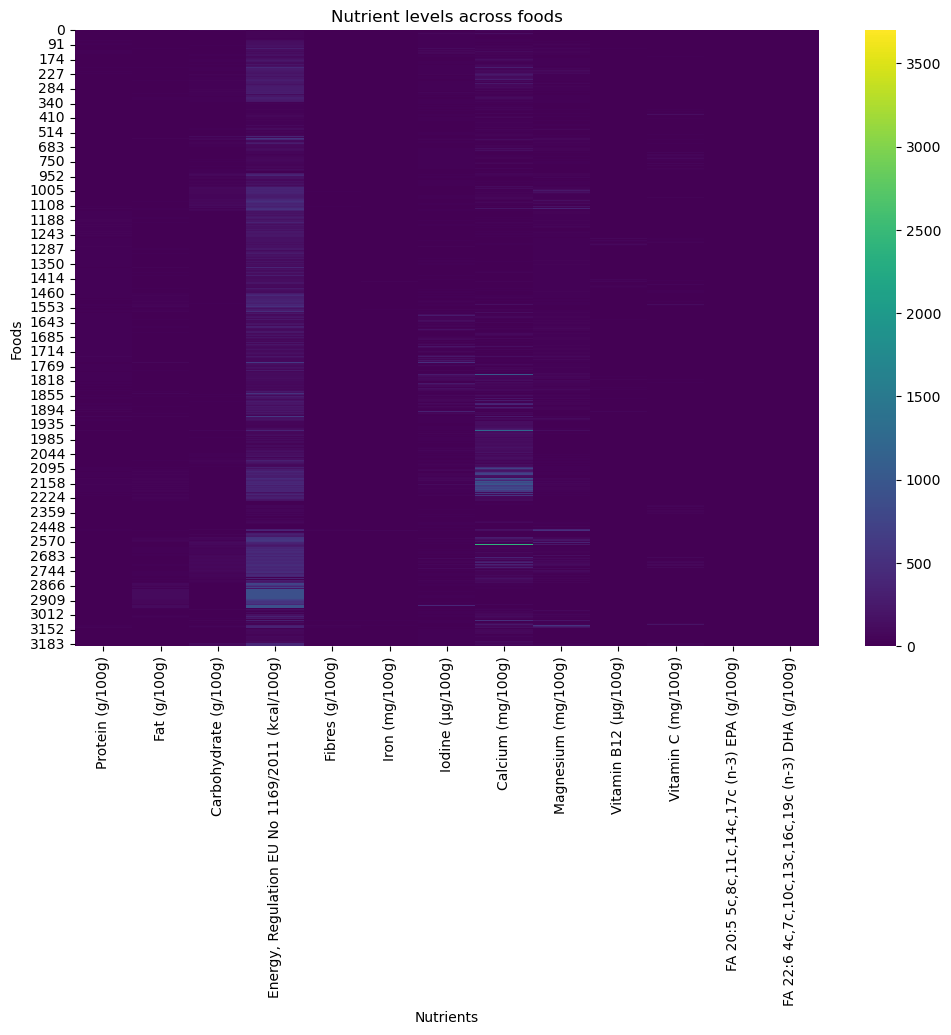

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_compare[nutrient_cols].astype(float).drop(columns = 'alim_code').dropna(), cmap="viridis")
plt.title("Nutrient levels across foods")
plt.xlabel("Nutrients")
plt.ylabel("Foods")
plt.show()

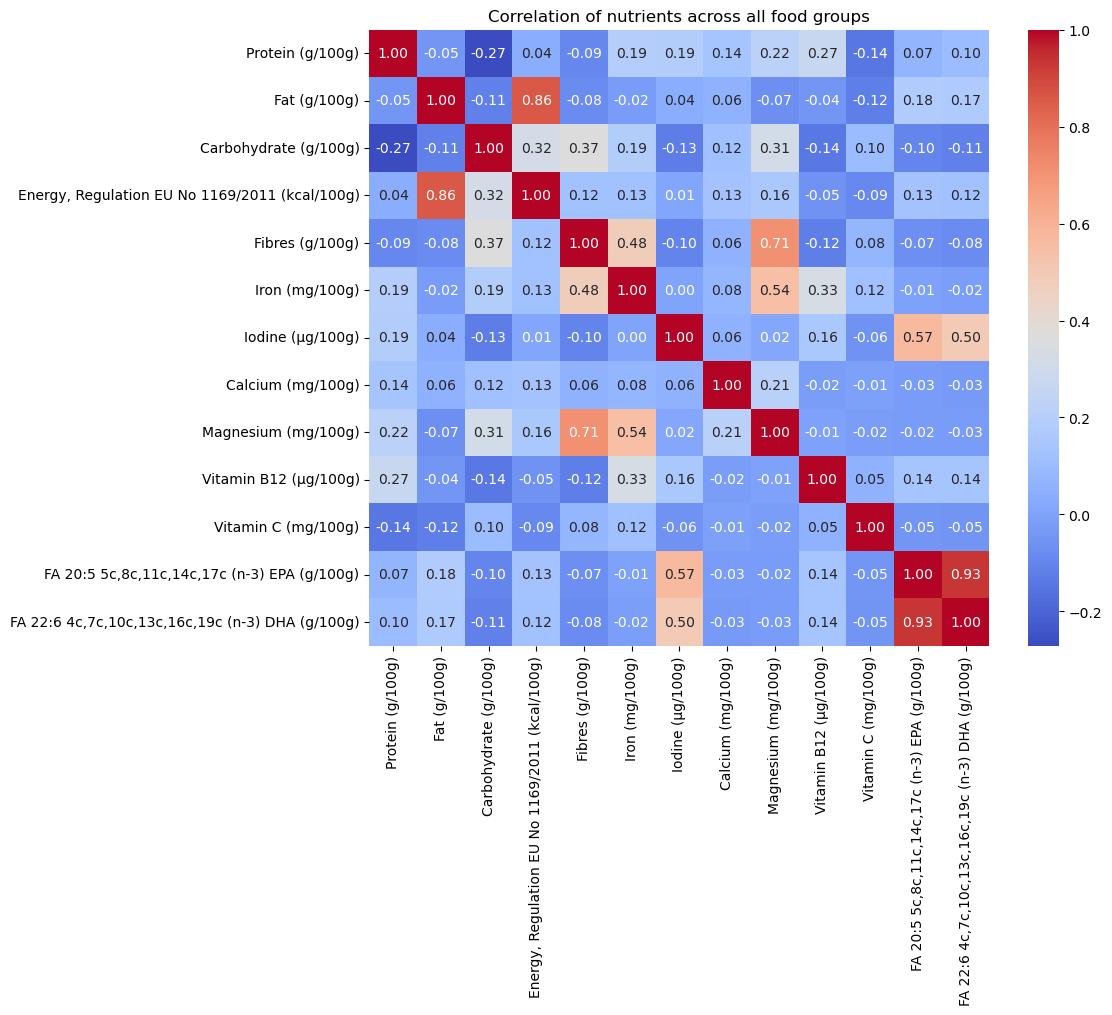

In [18]:
# Step 1: Select cleaned, numerical, nutrient columns
nutrient_data = df_compare[nutrient_cols].astype(float).drop(columns = 'alim_code').dropna()

# Calculate the correlation matrix
correlation_matrix = nutrient_data.corr()

# Create the heatmap
plt.figure(figsize = (10,8))
plt.title('Correlation of nutrients across all food groups')
sns.heatmap(correlation_matrix, annot=True, cmap = 'coolwarm', fmt=".2f")
plt.show()

### Correlation heatmap - across a subset of groups

In [19]:
# observe different subgroups to determine which to compare with "seaweed"
pd.set_option('display.max_rows', None) 
df_ciqual["alim_ssgrp_nom_eng"].value_counts()

alim_ssgrp_nom_eng
vegetables                                  303
delicatessen meat and similar               173
fruits                                      170
raw meat                                    162
dishes                                      159
non-alcoholic beverages                     156
dairy products and similar                  137
cheese and similar                          135
cooked meat                                 133
fish, raw                                   106
water                                        90
cakes and pastry                             85
sauces                                       75
pasta, rice and grains                       71
sweet biscuits                               65
fish, cooked                                 63
breads and similar                           56
fish products                                56
nuts and seeds                               52
potatoes and other tubers                    51
alcoholic beverages  

In [20]:
### focus on a specific subset of food groups

sub_groups = ["seaweed", "cooked meat", "fish, raw", "fish, cooked", "nuts and seeds", "eggs", "seafood, cooked"]

df_subset = df_compare.loc[df_compare["alim_ssgrp_nom_eng"].isin(sub_groups)]

df_subset.head()

,alim_code,alim_nom_eng,alim_grp_nom_eng,alim_ssgrp_nom_eng,Protein (g/100g),Fat (g/100g),Carbohydrate (g/100g),"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fibres (g/100g),Iron (mg/100g),Iodine (µg/100g),Calcium (mg/100g),Magnesium (mg/100g),Vitamin B12 (µg/100g),Vitamin C (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
900,9570.0,Chestnut flour,"fruits, vegetables, legumes and nuts",nuts and seeds,5.69,3.43,70.40,NaN,12.60,0.075,NaN,61.6,67.9,NaN,16.000,NaN,NaN
901,15000.0,"Almond, (with peel)","fruits, vegetables, legumes and nuts",nuts and seeds,18.80,51.30,9.51,NaN,12.50,3.400,15.0,260.0,270.0,0.0,0.375,0.0075,0.0075
902,15001.0,Peanut,"fruits, vegetables, legumes and nuts",nuts and seeds,22.80,49.10,14.80,NaN,8.60,1.600,15.0,57.0,190.0,0.0,0.375,0.0075,0.0075
903,15002.0,"Peanut, grilled, salted","fruits, vegetables, legumes and nuts",nuts and seeds,22.90,50.00,15.00,NaN,8.04,1.200,5.7,47.4,169.0,0.0,0.375,0.0000,0.0000
904,15004.0,Hazelnut,"fruits, vegetables, legumes and nuts",nuts and seeds,14.40,56.90,7.16,NaN,11.60,3.000,15.0,120.0,160.0,0.0,0.375,0.0075,0.0075


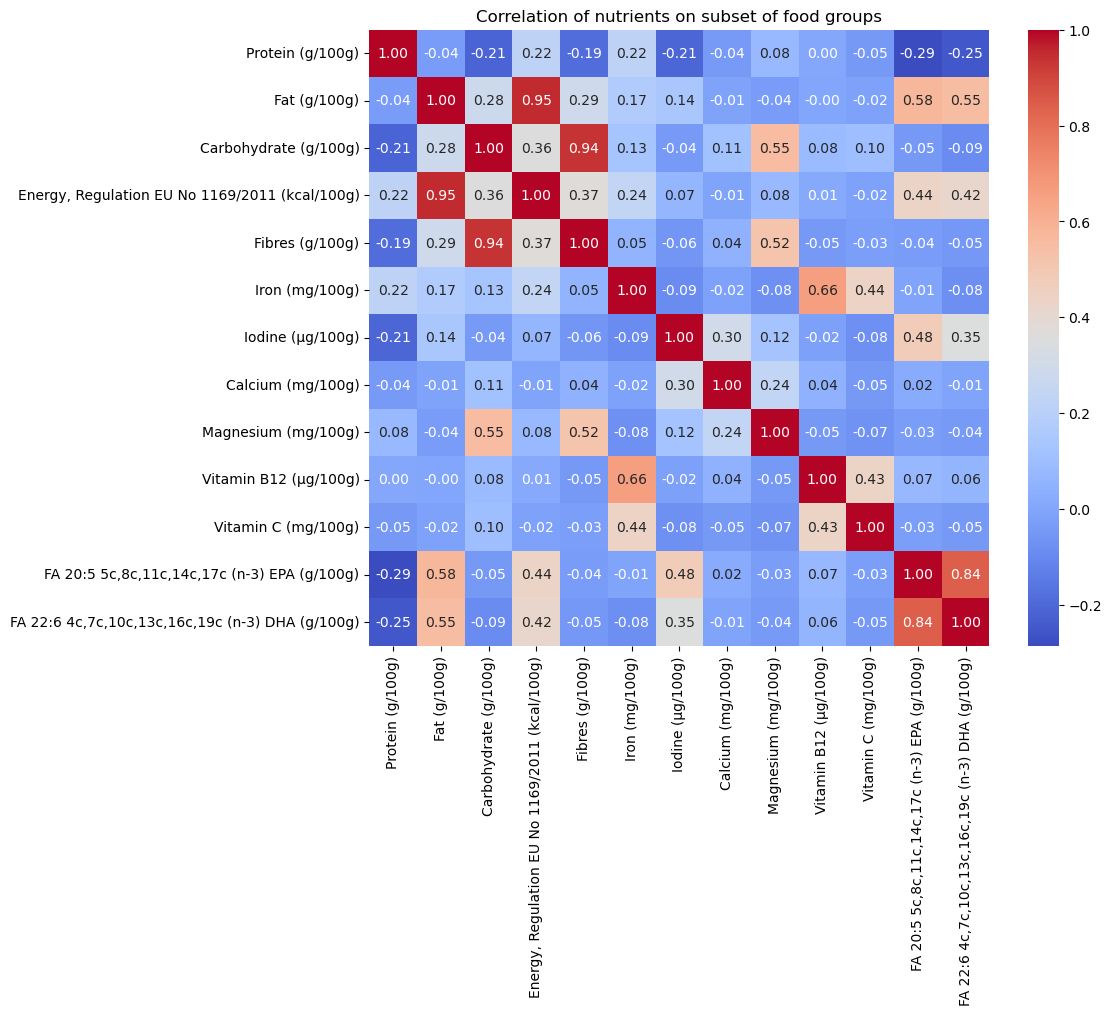

In [21]:
# Step 1: Select cleaned, numerical, nutrient columns
nutrient_df_subset = df_subset[nutrient_cols].astype(float).drop(columns = 'alim_code').dropna()

# Calculate the correlation matrix
correlation_matrix = nutrient_df_subset.corr()

# Create the heatmap
plt.figure(figsize = (10,8))
plt.title('Correlation of nutrients on subset of food groups')
sns.heatmap(correlation_matrix, annot=True, cmap = 'coolwarm', fmt=".2f")
plt.show()